In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Constants
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
BAR_WIDTH = 0.2
group_spacing = 0.4
code_palette = sns.color_palette("pastel", n_colors=8)
code_hatches = ["/", "\\", "//", "++", "xx", "**"]

def plot_logical_error_rate(csv_path, decoding_time=True, cycles=100):
    """
    Styled two-subplot figure with:
    - Points on top of bars with black edge, connected by lines
    - Background color for readout time plot (green ≤1.0, red >1.0)
    - Gray dashed grid
    """

    df = pd.read_csv(csv_path)
    df = df[df['cycles'] == cycles]

    # Filter by decoding_time
    if decoding_time:
        df = df[df['error_type'].str.endswith('_2', na=False)]
    else:
        df = df[~df['error_type'].str.endswith('_2', na=False)]

    # Parse error_type
    def parse_error_type(s):
        nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
        if len(nums) < 2:
            return None, None
        nums = nums[-3:]
        return float(nums[0]), float(nums[1])

    df[['error_multiplier', 'time']] = df['error_type'].apply(lambda x: pd.Series(parse_error_type(x)))
    df['logical_error_rate'] = pd.to_numeric(df['logical_error_rate'])
    distances = sorted(df['distance'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(WIDE_FIGSIZE * 1.3, HEIGHT_FIGSIZE * 1.8))

    # ------------------------------
    # Left plot (a): error multiplier
    # ------------------------------
    df_time_1 = df[df['time'] == 1]
    x_vals = sorted(df_time_1['error_multiplier'].dropna().unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)


    for i, d in enumerate(distances):
        values = []
        for xm in x_vals:
            subset = df_time_1[(df_time_1['error_multiplier'] == xm) & (df_time_1['distance'] == d)]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)
        axes[0].bar(x + i*BAR_WIDTH, values, width=BAR_WIDTH,
                    color=code_palette[i % len(code_palette)],
                    hatch=code_hatches[i % len(code_hatches)],
                    edgecolor='black', label=f"d={d}")
        # Points on top of bars with black edge
        axes[0].plot(x + i*BAR_WIDTH, values, '-o',
                     color=code_palette[i % len(code_palette)],
                     markersize=3, markeredgecolor='black')

    axes[0].margins(x=0)
    #axes[0].set_yscale("log")
    axes[0].set_xticks(x + BAR_WIDTH)
    axes[0].set_xticklabels([f"{xm:.2f}x" for xm in x_vals], fontsize=FONTSIZE-2)
    axes[0].set_xlabel("Scale of MCM error", fontsize=FONTSIZE)
    axes[0].set_ylabel("Logical error rate (log)", fontsize=FONTSIZE)
    axes[0].set_title("(a) MCM error rate", fontsize=FONTSIZE, fontweight="bold")
    axes[0].legend(fontsize=FONTSIZE-2, loc="upper left",)
    axes[0].text(0.53, 1.2, "Lower is better ↓", transform=axes[0].transAxes,
                 fontsize=FONTSIZE, fontweight="bold", color="blue", va="top", ha="center")
    axes[0].set_axisbelow(True)
    axes[0].grid(color='gray')

    # ------------------------------
    # Right plot (b): time
    # ------------------------------
    df_error_1 = df[df['error_multiplier'] == 1]
    x_vals = sorted(df_error_1['time'].dropna().unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)

    # Background coloring to the full plot
    axes[1].margins(x=0)
    #axes[1].set_yscale("log")
    axes[1].axvspan(-0.5, np.searchsorted(x_vals, 1.0) - 0.5, facecolor='green', alpha=0.1)
    axes[1].axvspan(np.searchsorted(x_vals, 1.0) - 0.5, np.searchsorted(x_vals, 1.0) + 3, facecolor='red', alpha=0.1)

    for i, d in enumerate(distances):
        values = []
        for t in x_vals:
            subset = df_error_1[(df_error_1['time'] == t) & (df_error_1['distance'] == d)]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)
        axes[1].bar(x + i*BAR_WIDTH, values, width=BAR_WIDTH,
                    color=code_palette[i % len(code_palette)],
                    hatch=code_hatches[i % len(code_hatches)],
                    edgecolor='black')
        axes[1].plot(x + i*BAR_WIDTH, values, '-o',
                     color=code_palette[i % len(code_palette)],
                     markersize=3, markeredgecolor='black')

    axes[1].set_xticks(x + BAR_WIDTH)
    axes[1].set_xticklabels([f"{t:.2f}" for t in x_vals], fontsize=FONTSIZE-2)
    axes[1].set_xlabel("Readout time (µs)", fontsize=FONTSIZE)
    axes[1].set_ylabel("Logical error rate (log)", fontsize=FONTSIZE)
    axes[1].set_title("(b) MCM duration", fontsize=FONTSIZE, fontweight="bold")
    axes[1].text(0.53, 1.2, "Lower is better ↓", transform=axes[1].transAxes,
                 fontsize=FONTSIZE, fontweight="bold", color="blue", va="top", ha="center")
    axes[1].set_axisbelow(True)
    axes[1].grid(color='gray')

    axes[0].tick_params(axis='both', labelsize=FONTSIZE-2)
    axes[1].tick_params(axis='both', labelsize=FONTSIZE-2)

    plt.tight_layout()
    plt.show()

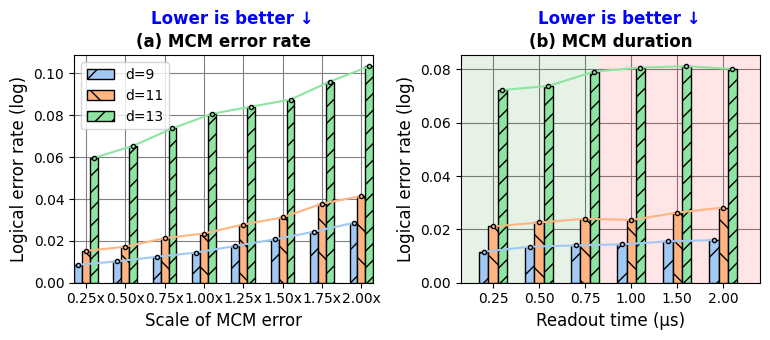

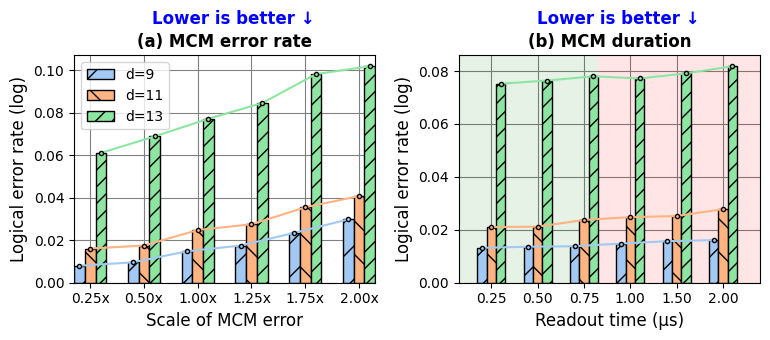

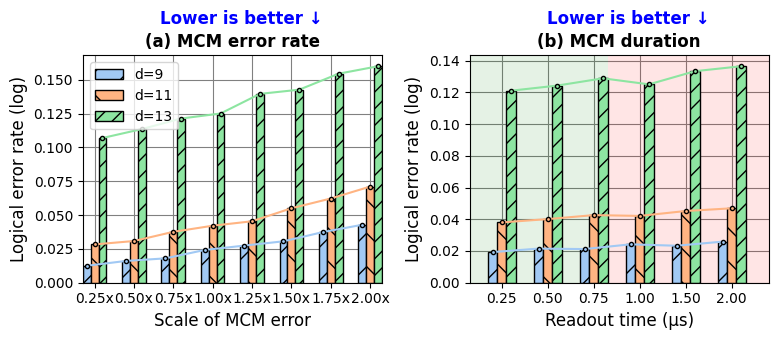

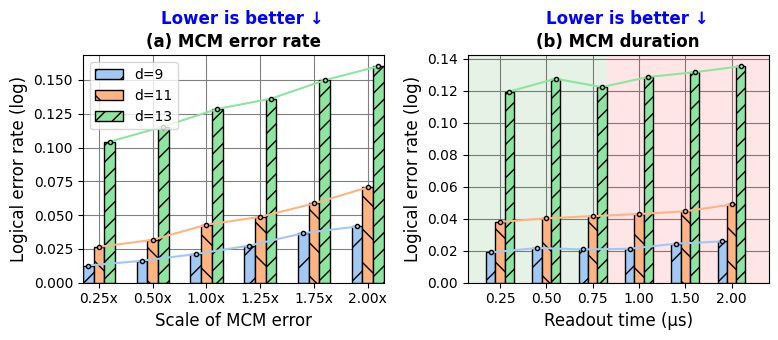

In [30]:
plot_logical_error_rate("../experiment_results/MCM/results.csv", False)
plot_logical_error_rate("../experiment_results/MCM/results.csv", True)
plot_logical_error_rate("../experiment_results/MCM/results.csv", False, 200)
plot_logical_error_rate("../experiment_results/MCM/results.csv", True, 200)

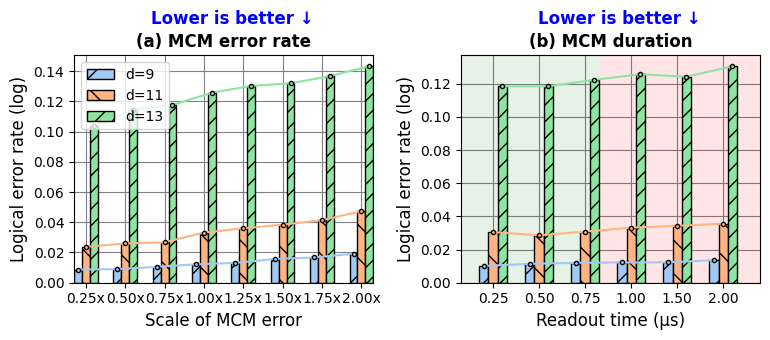

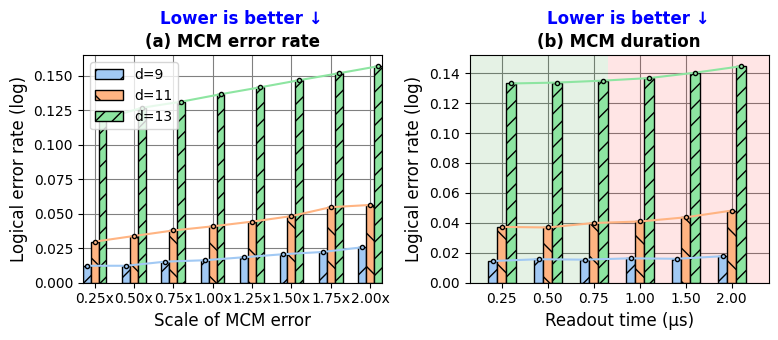

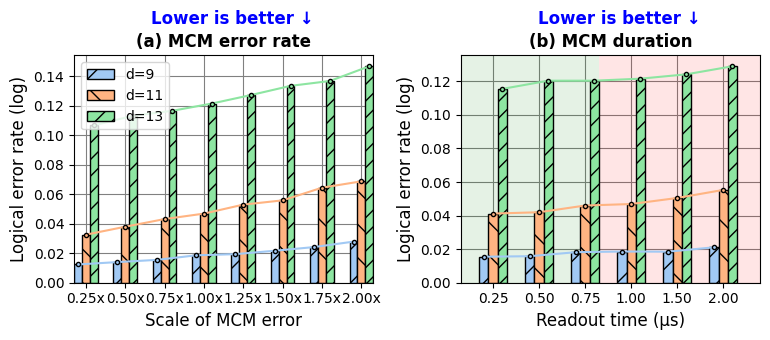

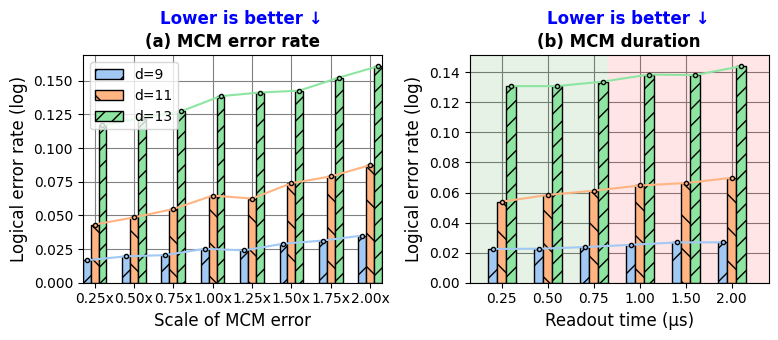

In [31]:
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", False)
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", True)
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", False, 200)
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", True, 200)

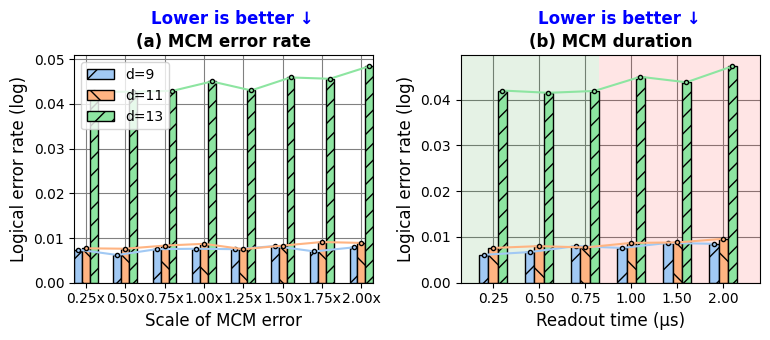

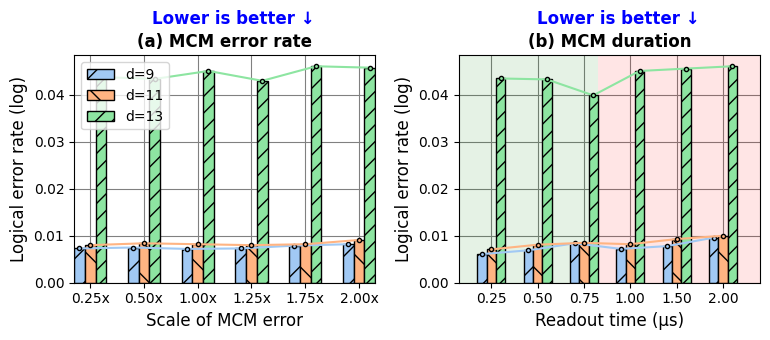

In [32]:
plot_logical_error_rate("../experiment_results/MCM_futuristic/results.csv", False)
plot_logical_error_rate("../experiment_results/MCM_futuristic/results.csv", True)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_time_only(csv_path):
    """
    Plots logical error rate vs time (µs).
    Shows grouped bars for distances (7, 9, 11).
    Assumes error_type format: mcm_<multiplier>_<time>
    """

    df = pd.read_csv(csv_path)

    # Extract multiplier and time from error_type
    def parse_error_type(s):
        nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
        if len(nums) < 2:
            return None, None
        multiplier = float(nums[0])
        time = float(nums[1])
        return multiplier, time

    df[["error_multiplier", "time"]] = df["error_type"].apply(
        lambda x: pd.Series(parse_error_type(x))
    )

    df["logical_error_rate"] = pd.to_numeric(df["logical_error_rate"])

    distances = sorted(df["distance"].unique())
    times = sorted(df["time"].unique())

    x = np.arange(len(times))
    bar_width = 0.25

    plt.figure(figsize=(8, 6))

    for i, d in enumerate(distances):
        values = []
        for t in times:
            subset = df[(df["distance"] == d) & (df["time"] == t)]
            values.append(
                subset["logical_error_rate"].values[0]
                if not subset.empty else np.nan
            )

        plt.bar(x + i * bar_width, values, width=bar_width, label=f"d={d}")

    plt.xticks(x + bar_width, times)
    plt.yscale("log")
    plt.xlabel("Time (µs)")
    plt.ylabel("Logical Error Rate")
    plt.title("Logical Error Rate vs Time")
    plt.legend()

    plt.tight_layout()
    plt.show()

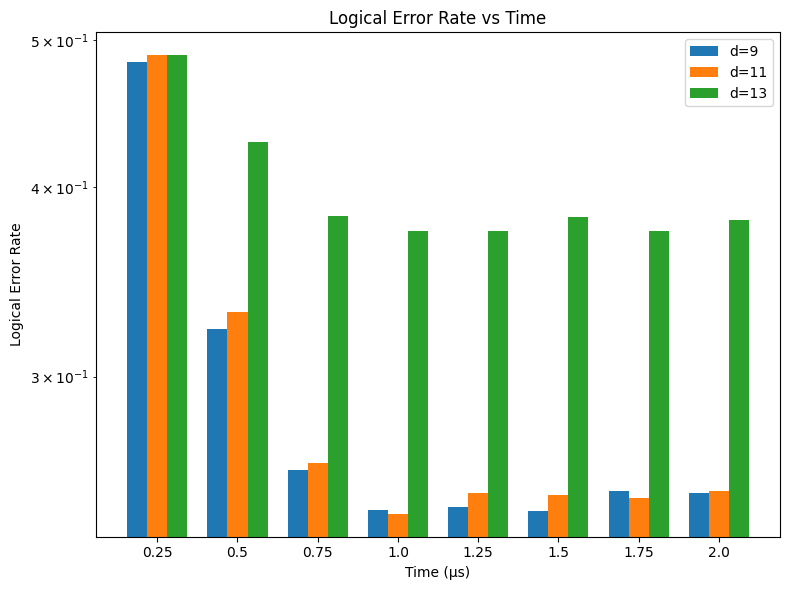

In [11]:
plot_time_only("../experiment_results/MCM_tradeoff/results.csv")

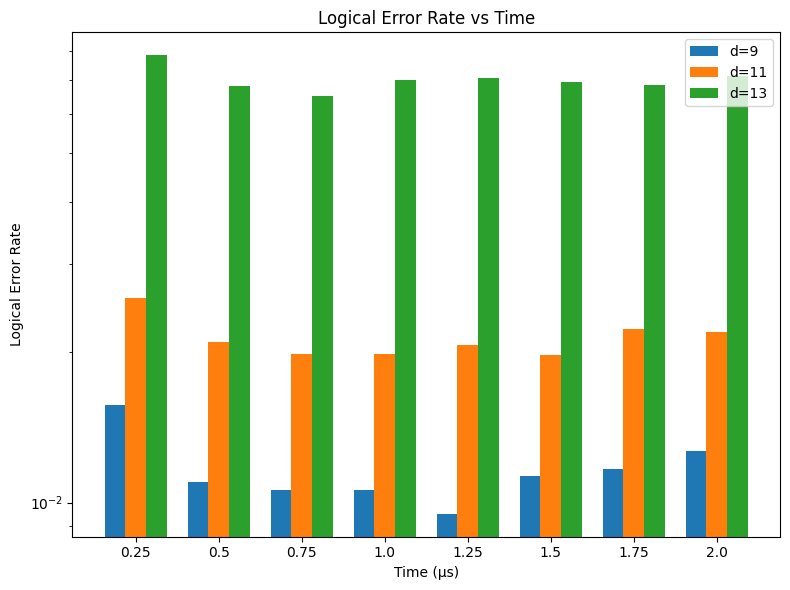

In [27]:
plot_time_only("../experiment_results/MCM_tradeoff_futuristic/results.csv")

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Constants
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
code_palette = sns.color_palette("pastel", n_colors=8)
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

def plot_logical_error_vs_cycles(csv_path, dist=9):
    """
    Linear plot:
    - X-axis: cycles
    - Y-axis: logical error rate
    - Only distance = 9
    - One line per error_type
    """

    df = pd.read_csv(csv_path)
    df = df[df["distance"] == dist]   # 🔹 Filter to distance 9
    df["logical_error_rate"] = pd.to_numeric(df["logical_error_rate"])

    fig, ax = plt.subplots(figsize=(WIDE_FIGSIZE*2, HEIGHT_FIGSIZE*3))

    unique_error_types = sorted(df["error_type"].unique())

    for i, et in enumerate(unique_error_types):
        subset = df[df["error_type"] == et].sort_values("cycles")

        ax.plot(
            subset["cycles"],
            subset["logical_error_rate"],
            marker=markers[i % len(markers)],
            color=code_palette[i % len(code_palette)],
            linewidth=1.8,
            markersize=6,
            label=et
        )

    ax.set_xlabel("Cycles", fontsize=FONTSIZE)
    ax.set_ylabel("Logical Error Rate", fontsize=FONTSIZE)

    ax.set_title("(a) Logical Error Rate vs Cycles (d=9)",
                 fontsize=FONTSIZE,
                 fontweight="bold",
                 pad=15)

    ax.legend(fontsize=FONTSIZE)

    ax.text(
        1.0, 1.16, "Lower is better ↓",
        transform=ax.transAxes,
        fontsize=FONTSIZE,
        fontweight="bold",
        color="blue",
        va="top",
        ha="right"
    )

    plt.show()

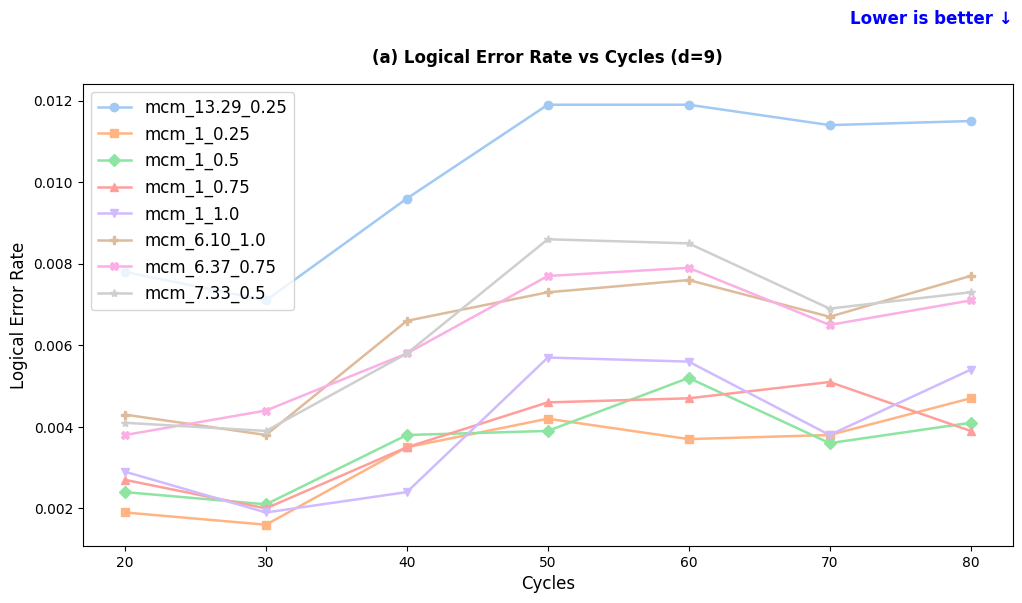

In [28]:
plot_logical_error_vs_cycles("../experiment_results/MCM_cycles/results.csv", 9)